# Evaluation Plots for paper

In [3]:
!rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/test.db /home/phahn/repositories/dal-toolbox/publications/cleaning_the_pool/

receiving incremental file list
test.db

sent 43 bytes  received 415,366 bytes  276,939.33 bytes/sec
total size is 3,198,976  speedup is 7.70


In [4]:
import os
import mlflow
import numpy as np
import pylab as plt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from collections import defaultdict
from pathlib import Path
from cycler import cycler
import time
import datetime

# Define a custom style dictionary
custom_style = {
    # Figure and axes
    "figure.figsize": (3, 2),
    "figure.dpi": 100,
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    # Lines and markers
    "lines.linewidth": 1.5,
    "lines.markersize": 6,
    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    # Save figure settings
    "savefig.dpi": 300,
    # "axes.spines.top": False,
    # "axes.spines.right": False,
}

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
mpl.rcParams.update(custom_style)
mpl.rcParams['axes.grid'] = True
mpl.rcParams["grid.linestyle"] = '--'
mpl.rcParams["grid.linewidth"] = .5
mpl.rcParams["grid.alpha"] = 0.7
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#6C8EBF", "#D45D5D", "#5C985C", "#D9822B", "#65406B", "#DAB66C", "#A2D5C6", "#E699B3"])

plot_dir = Path('/home/phahn/paper_plots/adaptive_al/')
os.makedirs(plot_dir, exist_ok=True)

uri =   'sqlite://///home/phahn/repositories/dal-toolbox/publications/cleaning_the_pool/test.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
print([(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()])

2026/02/13 09:06:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/13 09:06:51 INFO mlflow.store.db.utils: Updating database tables
2026-02-13 09:06:51 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2026-02-13 09:06:51 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2026-02-13 09:06:51 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2026-02-13 09:06:51 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


[('autoal_test', '12-02-26'), ('Default', '12-02-26')]


In [5]:
def get_runs(uri, exp_name, query_list="", after=None, before=None, **kwargs):
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    experiment_id = client.get_experiment_by_name(exp_name).experiment_id
    max_res = kwargs.get('max_results', 10000)
    runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list), max_results=max_res)
    if after is not None:
        runs = [run for run in runs if (run.info.end_time / 1000) > after]
    if before is not None:
        runs = [run for run in runs if (run.info.end_time / 1000) < before]
    runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))
    return runs

def get_metric(run, uri, metric):
    client = mlflow.tracking.MlflowClient(uri)
    m_values = [m.value for m in client.get_metric_history(run.info.run_id, metric)]
    return m_values

def get_avg_lc(runs, uri, metric='accuracy', return_std=False):
    lcs = []
    for run in runs:
        m_values = get_metric(run, uri, metric)
        if len(m_values) == 0:
            print(f'No metric values found for run {run.info.run_id}.')
        if len(m_values) != 21:
            continue
        lcs.append(m_values)
    avg_lc = np.mean(lcs, axis=0)
    if return_std:
        std_lc = np.std(lcs, axis=0)
        return avg_lc, std_lc 
    return avg_lc
    
def get_axis_from_run(run):
    acq_size = eval(run.data.params['dataset.acq_size'])
    num_acq = eval(run.data.params['dataset.num_acq'])
    budget = acq_size + num_acq*acq_size
    axis = np.arange(acq_size, budget+1, acq_size)
    return axis

In [6]:
exp_name = 'autoal_test'

all_strategies = ['random', 'uncertainty_herding', 'autoal']

datasets = ['cifar10', 'dopanim', 'cifar100'] #TODO: Await AutoAL results
backbones = ['dinov3']

all_lcs = {}

for bb in backbones:
    if bb not in all_lcs:
        all_lcs[bb] = {}
    for dset in datasets:
        if dset not in all_lcs[bb]:
            all_lcs[bb][dset] = {}
        for strat in all_strategies:
            all_lcs[bb][dset][strat] = {}
            runs = get_runs(uri, exp_name, [f"parameter.dataset.name = '{dset}'", f"parameter.al.strategy = '{strat}'", f"parameter.model.backbone = '{bb}'"])
            runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))
            for run in runs:
                seed = run.data.params['random_seed']
                accs = get_metric(run, uri, 'accuracy')
                if len(accs) == 21: #TODO: Fixme hardcoded
                    all_lcs[bb][dset][strat][seed] = accs
                else:
                    print("Run with not enough acc values?=", bb, dset, strat, seed)

In [7]:
all_lcs_array = {}
seeds = [str(i) for i in range(1,11)]

for bb in backbones:
    all_lcs_array[bb] = {}
    for dset in datasets:
        all_lcs_array[bb][dset] = {}
        for strat in all_strategies:
            if len(all_lcs[bb][dset][strat].values()) == 0:
                print("Experiment Missing:", bb, dset, strat)
            elif len(all_lcs[bb][dset][strat].values()) != 10:
                for seed in seeds:
                    if seed not in all_lcs[bb][dset][strat]:
                        print(f'"{strat},{dset},{bb},{seed}"')
            else:
                all_lcs_array[bb][dset][strat] = np.array(list(all_lcs[bb][dset][strat].values()))

Experiment Missing: dinov3 cifar100 autoal


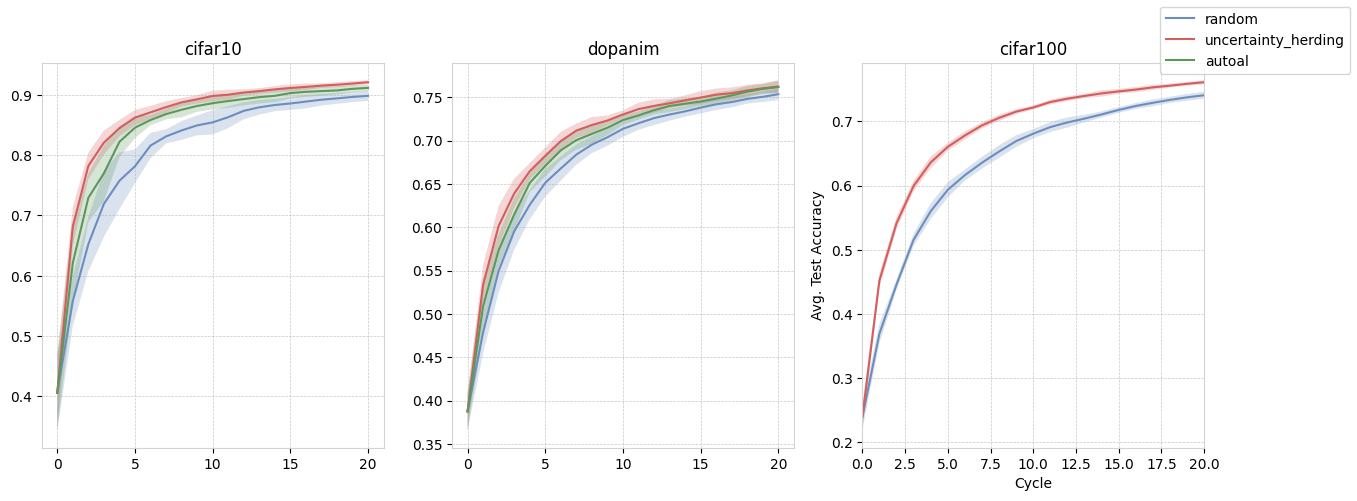

In [22]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

for i, dset in enumerate(all_lcs_array['dinov3']):
    plt.axes(ax[i])
    plt.title(dset)
    for strat in all_lcs_array['dinov3'][dset]:
        plt.plot(range(21), np.mean(all_lcs_array['dinov3'][dset][strat], axis=0), label=strat)
        plt.fill_between(x=range(21), y1=np.mean(all_lcs_array['dinov3'][dset][strat], axis=0) - np.std(all_lcs_array['dinov3'][dset][strat], axis=0), 
                         y2=np.mean(all_lcs_array['dinov3'][dset][strat], axis=0) + np.std(all_lcs_array['dinov3'][dset][strat], axis=0), alpha=0.25)
handles = []
labels = []

for a in ax:
    h, l = a.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Remove duplicates while preserving order
unique = dict(zip(labels, handles))
plt.xlabel("Cycle")
plt.xlim(0,20)
plt.ylabel("Avg. Test Accuracy")
fig.legend(unique.values(), unique.keys())
plt.show()

In [10]:
from scipy import stats
from matplotlib import patheffects

def create_pairwise_comparison_matrix(lc_dict, alpha=0.05):
    strategy_names = list(lc_dict.keys())
    n_strategies = len(strategy_names)
    
    # Initialize comparison matrix
    matrix = np.zeros((n_strategies, n_strategies))
    
    # Get number of cycles from first strategy
    num_seeds, num_cycles = list(lc_dict.values())[0].shape
    
    # Compare each pair of lc_dict
    for i, strat_i in enumerate(strategy_names):
        for j, strat_j in enumerate(strategy_names):
            if i == j:
                continue
            
            curves_i = lc_dict[strat_i]
            curves_j = lc_dict[strat_j]
            
            wins = 0
            for cycle in range(1, num_cycles): # first cycle is identical due to same init set
                for seed in range(num_seeds):
                    acc_i = curves_i[seed, cycle]
                    acc_j = curves_j[seed, cycle]

                    if acc_i > acc_j:
                        wins += 1
                
                # Paired t-test and check if i significantly outperforms j
                # t_stat, p_value = stats.ttest_rel(acc_i, acc_j)
                # if p_value < alpha and np.mean(acc_i) > np.mean(acc_j):
                #     wins += 1
            matrix[i, j] = wins / (num_cycles*num_seeds)
    
    return matrix, strategy_names

all_models = backbones
strat_order = ['random', 'margin', 'badge', 'typiclust', 'alfamix', 'dropquery', 'bait', 'max_herding', 'uncertainty_herding', 'tailor2', 'select_al', 'tcm', 'autoal2', 'refine']
all_mats = []
for model in all_models:
    for dataset in datasets:
        mat, names = create_pairwise_comparison_matrix(all_lcs_array[model][dataset])
        all_mats.append(mat)
avg_mat = np.mean(all_mats, axis=0)


strat_presentation_names = {'random':"Random", 'margin':'Margin', 'alfamix':'AlfaMix', 'badge':'BADGE', 'typiclust':'TypiClust', 'dropquery':'DropQuery', 'max_herding':'MaxHerding',
                            'uncertainty_herding':'UHerding', 'tailor2':'TAILOR', 'autoal2':'AutoAL', 'tcm':'TCM', 'select_al':'SelectAL', 'bait':'BAIT', 'refine':'Refine'}
indices_order = [names.index(s) for s in strat_order]

avg_mat = avg_mat[np.ix_(indices_order, indices_order)]
names = [strat_presentation_names[names[i]] for i in indices_order]

plt.figure(figsize=(10, 8))
plt.grid()
plt.imshow(avg_mat, cmap='coolwarm')
for i in range(len(names)):
    for j in range(len(names)):
        text = plt.text(j, i, f'{avg_mat[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')
        text.set_path_effects([patheffects.Stroke(linewidth=1.2, foreground='white'), patheffects.Normal()])

plt.xticks(range(len(mat)), names, rotation=90)
plt.yticks(range(len(mat)), names)
#plt.savefig(plot_dir / f'avg_pairwise_comparison_matrix.pdf', bbox_inches='tight')
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

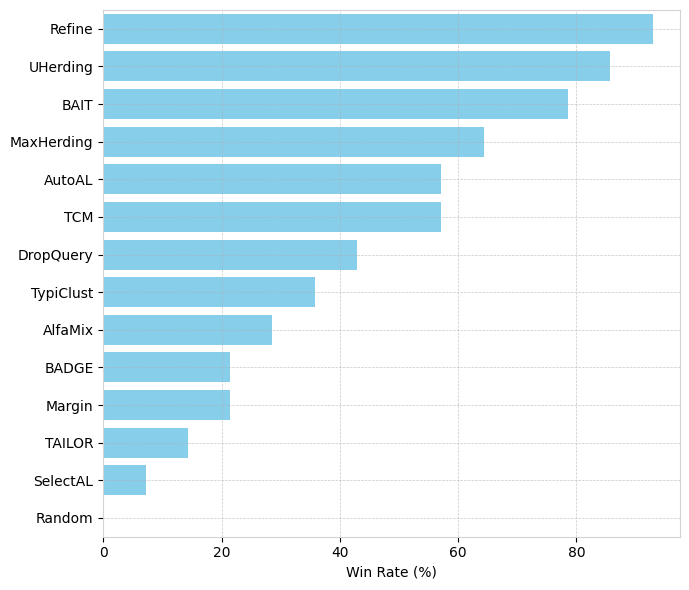

In [50]:
# Compute win rate (fraction of pairwise wins)
win_rate = np.nanmean(avg_mat > 0.5, axis=1) * 100

# --- Sort by win rate ---
sorted_indices = np.argsort(win_rate)        # ascending order
sorted_names = [names[i] for i in sorted_indices]
sorted_win_rate = win_rate[sorted_indices]

# --- Plot ---
plt.figure(figsize=(7, 6))
plt.barh(sorted_names, sorted_win_rate, color='skyblue')
plt.xlabel("Win Rate (%)")
plt.gca().invert_yaxis()  # optional: highest at top
plt.tight_layout()
plt.ylim(-.5, 13.5)
plt.show()

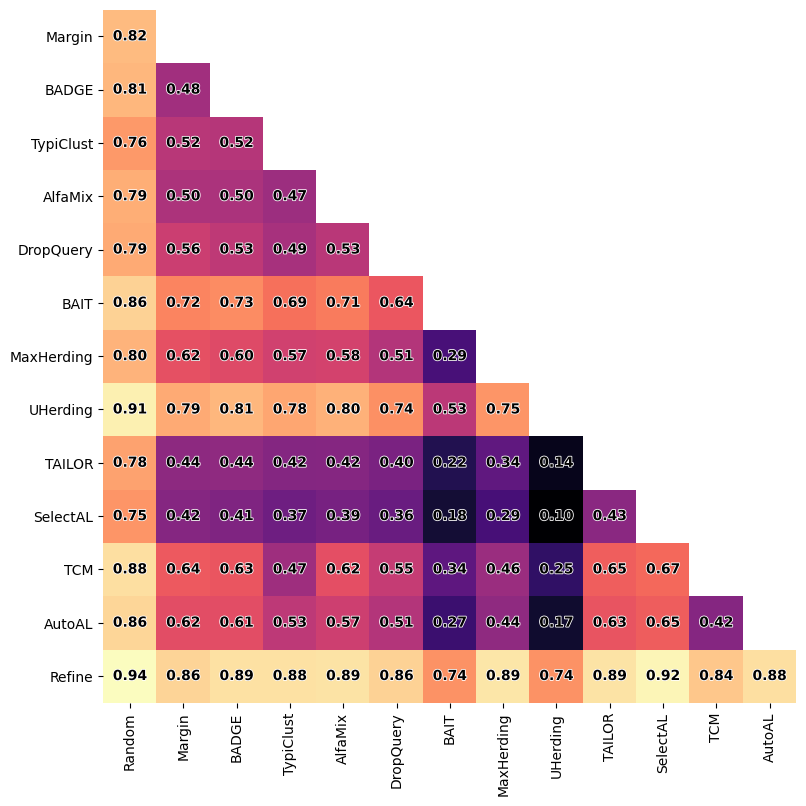

In [41]:
new_avg_mat = avg_mat[1:,][:,:-1]
mask = np.triu(np.ones_like(new_avg_mat, dtype=bool), k=1)  # upper triangle mask

plt.figure(figsize=(10, 9))
plt.imshow(np.ma.array(new_avg_mat, mask=mask), cmap='magma')
for i in range(len(names)-1):
    for j in range(len(names)-1):
        if i >= j:
            text = plt.text(j, i, f'{new_avg_mat[i, j]:.2f}',
                        ha="center", va="center", color="black", fontsize=10, fontweight='bold')
            text.set_path_effects([patheffects.Stroke(linewidth=1.2, foreground='white'), patheffects.Normal()])
plt.xticks(range(len(names)-1), names[:-1], rotation=90)
plt.yticks(range(len(names)-1), names[1:])
plt.grid(False)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

KeyError: 'food101'

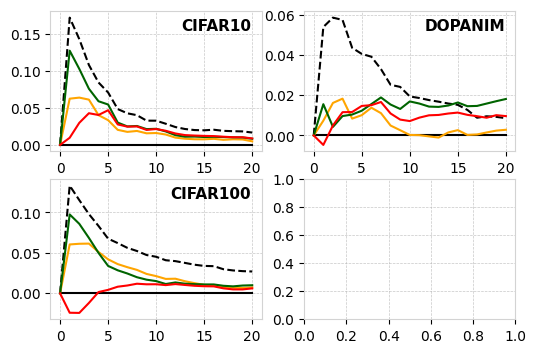

In [11]:
plot_kwargs = {
    'random':               dict(ls='-' , color='black', label='Random'),
    'refine':               dict(ls='--', color='black', label='Refine'),
    'tcm':                  dict(ls='-', color='darkgreen', label='TCM'),
    'tailor2':              dict(ls='-', color='red', label='TAILOR'),
    'select_al':            dict(ls='-', color='orange', label='SelectAL'),
}
for model in backbones:
    datasets = ['cifar10', 'dopanim', 'cifar100', 'food101']
    strats = ['random', 'refine', 'select_al', 'tcm', 'tailor2']

    fig, ax = plt.subplots(figsize=(6, 4), ncols=2, nrows=2)
    ax = ax.flatten()

    absolute = False
    for i_ds, ds in enumerate(datasets):
        plt.sca(ax[i_ds])
        avg_lc_random = np.mean(all_lcs_array[model][ds]['random'], 0)
        for strat in strats:
            avg_lc = np.mean(all_lcs_array[model][ds][strat], 0)
            target = avg_lc 
            target -= 0 if absolute else avg_lc_random 
            plt.plot(target, **plot_kwargs[strat])

        text_y_pos = 0.15 if absolute else 0.95
        ax[i_ds].text(0.95, text_y_pos, ds.upper(), 
                    transform=ax[i_ds].transAxes,
                    fontsize=11, fontweight='bold',
                    verticalalignment='top',
                    horizontalalignment='right')

    plt.tight_layout()
    ax[0].legend(bbox_to_anchor=(0, 1.3), loc='upper left', ncol=5)
    plt.show()